In [11]:
import pandas as pd
import bz2
import re
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

In [12]:
reviews = []

with bz2.open("test.ft.txt.bz2", "rt", encoding="utf-8") as f:
    for i, line in enumerate(f):
        review = re.sub(r'__label__[12]\s+', '', line)
        reviews.append(review)
        if i == 50000:    
            break

df = pd.DataFrame(reviews, columns=["review"])

In [13]:
print("Total Reviews:", len(df))
print("Missing Values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

df["word_count"] = df["review"].apply(lambda x: len(x.split()))

print(df["word_count"].describe())

Total Reviews: 50001
Missing Values: 0
Duplicates: 0
count    50001.000000
mean        79.935961
std         43.196507
min         13.000000
25%         43.000000
50%         72.000000
75%        110.000000
max        210.000000
Name: word_count, dtype: float64


In [14]:
def clean_text(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^A-Za-z0-9\s]', '', text)
    return text.lower()

df["clean_review"] = df["review"].apply(clean_text)

In [15]:
vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words='english',
    max_features=10
)

X = vectorizer.fit_transform(df["clean_review"])

print("\nTop Bigrams:")
print(vectorizer.get_feature_names_out())


Top Bigrams:
['book read' 'dont buy' 'dont know' 'dont waste' 'great book'
 'highly recommend' 'read book' 'waste money' 'waste time' 'year old']


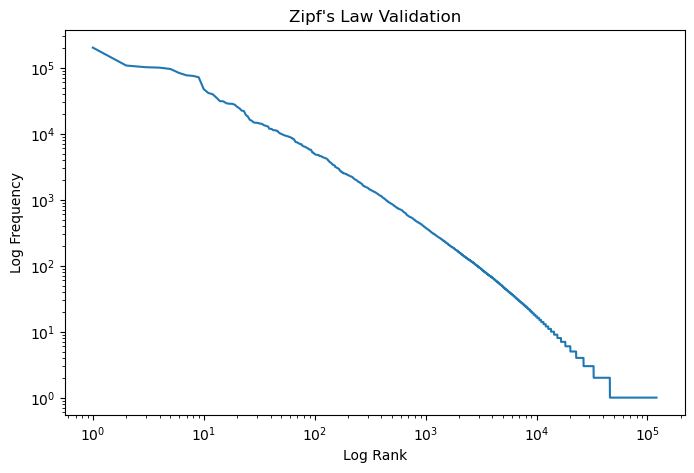

In [16]:
words = " ".join(df["clean_review"]).split()

freq = sorted(Counter(words).values(), reverse=True)

ranks = range(1, len(freq)+1)

plt.figure(figsize=(8,5))
plt.plot(ranks, freq)
plt.xscale('log')
plt.yscale('log')
plt.title("Zipf's Law Validation")
plt.xlabel("Log Rank")
plt.ylabel("Log Frequency")
plt.show()


In [17]:
stopwords = {
    'the','a','an','is','are','was','were',
    'in','on','at','to','of','for','and'
}

def stopword_ratio(text):
    words = text.split()
    stop_count = sum(1 for w in words if w in stopwords)
    return stop_count / len(words) if words else 0

df["stop_ratio"] = df["clean_review"].apply(stopword_ratio)

print("\nAverage Stopword Ratio:",
      round(df["stop_ratio"].mean(),3))


Average Stopword Ratio: 0.214


In [18]:
df.to_csv("cleaned_reviews.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
